<a href="https://colab.research.google.com/github/kartikirasane27/31_Kartiki-Rasane/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Learning Rate: 0.001 Epochs: 20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Learning Rate: 0.001 Epochs: 50
Learning Rate: 0.001 Epochs: 100
Learning Rate: 0.01 Epochs: 20
Learning Rate: 0.01 Epochs: 50
Learning Rate: 0.01 Epochs: 100
Learning Rate: 0.1 Epochs: 20
Learning Rate: 0.1 Epochs: 50
Learning Rate: 0.1 Epochs: 100

Performance Comparison:


,Learning Rate,Epochs,Test Accuracy (%),Test Loss
0,0.001,20,80.00,0.4668
1,0.001,50,83.33,0.3184
2,0.001,100,93.33,0.1523
3,0.010,20,96.67,0.0567
4,0.010,50,96.67,0.0506
5,0.010,100,96.67,0.0709
6,0.100,20,96.67,0.1229
7,0.100,50,96.67,0.0701
8,0.100,100,93.33,0.8013


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


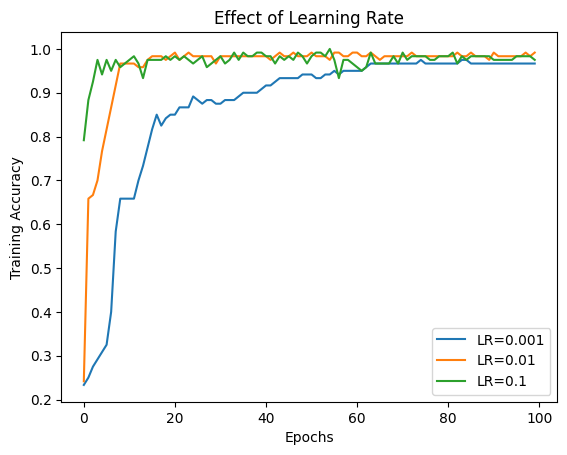

Predicted Class: 0
Actual Class: 0


In [1]:
# Install TensorFlow
!pip install tensorflow -q

# Import libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Normalize input features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Function to create MLP model
def create_model(learning_rate):

    model = Sequential([
        Dense(10, activation="relu", input_shape=(4,)),
        Dense(10, activation="relu"),
        Dense(3, activation="softmax")
    ])

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Learning rates and epochs to compare
learning_rates = [0.001, 0.01, 0.1]
epochs_list = [20, 50, 100]

results = []

# Train models with different learning rates and epochs
for lr in learning_rates:

    for epochs in epochs_list:

        print("Learning Rate:", lr, "Epochs:", epochs)

        model = create_model(lr)

        history = model.fit(
            X_train,
            y_train,
            epochs=epochs,
            batch_size=16,
            verbose=0
        )

        # Evaluate model
        loss, accuracy = model.evaluate(
            X_test,
            y_test,
            verbose=0
        )

        results.append([
            lr,
            epochs,
            round(accuracy * 100, 2),
            round(loss, 4)
        ])

# Display comparison
results = pd.DataFrame(
    results,
    columns=[
        "Learning Rate",
        "Epochs",
        "Test Accuracy (%)",
        "Test Loss"
    ]
)

print("\nPerformance Comparison:")
display(results)

# Plot effect of learning rate
for lr in learning_rates:

    model = create_model(lr)

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=16,
        verbose=0
    )

    plt.plot(
        history.history["accuracy"],
        label=f"LR={lr}"
    )

plt.xlabel("Epochs")
plt.ylabel("Training Accuracy")
plt.title("Effect of Learning Rate")
plt.legend()
plt.show()

# Demonstrate forward propagation
sample = X_test[0:1]

prediction = model.predict(sample, verbose=0)

print("Predicted Class:", np.argmax(prediction))
print("Actual Class:", y_test[0])